# **EXP B - 03: NeuralLW MLP Online Training**

## **0. Setup**

In [1]:
# Load packages
using Revise
using NeuralParam
using Plots

In [2]:
# Define experiments and general settings
EXP = "exp_B"

OUTPUT_FORMS  = ["direct", "linear", "planck"]
COLORS_OF = [JL_BLUE, JL_GREEN, JL_RED];

In [3]:
# Define offline runs

# Series
SER_OFF  = "01_NLW_MLP_offline"

# Schemes / Rollouts
OFF = ["$(name)_w064_h3" for name in OUTPUT_FORMS];

In [4]:
# Define offline runs

# Series
SER_ON = "03_NLW_MLP_online";

# Schemes / Rollouts
# XXX

"03_NLW_MLP_online"

### 0.1. Reference Sanity Check

In [5]:
# Reference sanity check
ref_weather = collect_rollouts(EXP, SER_ON, ["0_OBLW"]; leg = :weather).var"0_OBLW"
test_reference(ref_weather)

┌ Info: Reference reproduced exactly: every probe and IC is zero at the first lead time.
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_rollout.jl:1008


Row,probe,ic,max_first,exact
,String,Int64,Float32,Bool
1,T,1,0.0,true
2,olw,1,0.0,true
3,slwd,1,0.0,true
4,T,2,0.0,true
5,olw,2,0.0,true
6,slwd,2,0.0,true


In [6]:
# Reference sanity check
ref_climate = collect_rollouts(EXP, SER_ON, ["0_OBLW"]; leg = :climate).var"0_OBLW"
test_reference(ref_climate)

┌ Info: Reference reproduced exactly: every probe and IC is zero at the first lead time.
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_rollout.jl:1008


Row,probe,ic,max_first,exact
,String,Int64,Float32,Bool
1,T,1,0.0,true
2,olw,1,0.0,true
3,slwd,1,0.0,true
4,T,2,0.0,true
5,olw,2,0.0,true
6,slwd,2,0.0,true
7,T,3,0.0,true
8,olw,3,0.0,true
9,slwd,3,0.0,true


## **1. Training**

## **2. Skill Plane**

In [6]:
# Prepare skill plane plot

# Define units
units_off = OFF

units_on = [
    "direct_eta13_s1", "direct_eta13_s2", "direct_eta13_s3",
    "direct_eta54_s1", "direct_eta54_s2", "direct_eta54_s3",

    "linear_eta13_s1", "linear_eta13_s2", "linear_eta13_s3",
    "linear_eta54_s1", "linear_eta54_s2", "linear_eta54_s3",

    "planck_eta13_s1", "planck_eta13_s2", "planck_eta13_s3",
    "planck_eta54_s1", "planck_eta54_s2", "planck_eta54_s3",
]

# Collect weather and climate rollouts
w = merge(collect_rollouts(EXP, SER_OFF, units_off; leg = :weather), collect_rollouts(EXP, SER_ON, units_on; leg = :weather))
c = merge(collect_rollouts(EXP, SER_OFF, units_off; leg = :climate), collect_rollouts(EXP, SER_ON, units_on; leg = :climate))

# Create skill table
df = skill_table(w, c);

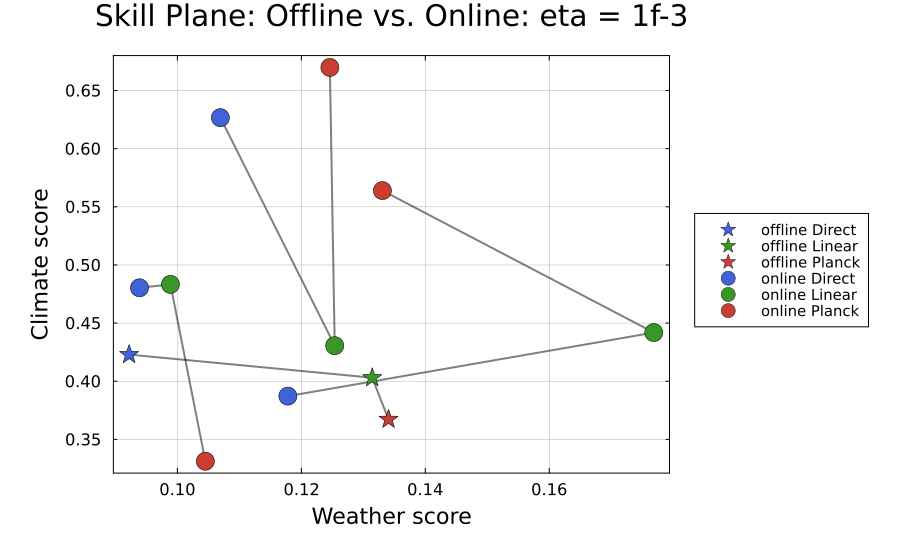

In [8]:
# Define styles and grouping
size_markers = 10

style = (;
    direct_w064_h3 = (; color = JL_BLUE,    size = size_markers, shape = :star,  label = "offline Direct", group = :XXX),
    linear_w064_h3 = (; color = JL_GREEN,   size = size_markers, shape = :star,  label = "offline Linear", group = :XXX),
    planck_w064_h3 = (; color = JL_RED,     size = size_markers, shape = :star,  label = "offline Planck", group = :XXX), 


    direct_eta13_s1 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s1),
    direct_eta13_s2 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s2),
    direct_eta13_s3 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s3),

    linear_eta13_s1 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s1),
    linear_eta13_s2 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s2),
    linear_eta13_s3 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s3),

    planck_eta13_s1 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s1),
    planck_eta13_s2 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s2),
    planck_eta13_s3 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s3),
)


# Plot skill plane
plot_skill_plane(df; style, trace_color = :black, title = "Skill Plane: Offline vs. Online: eta = 1f-3")

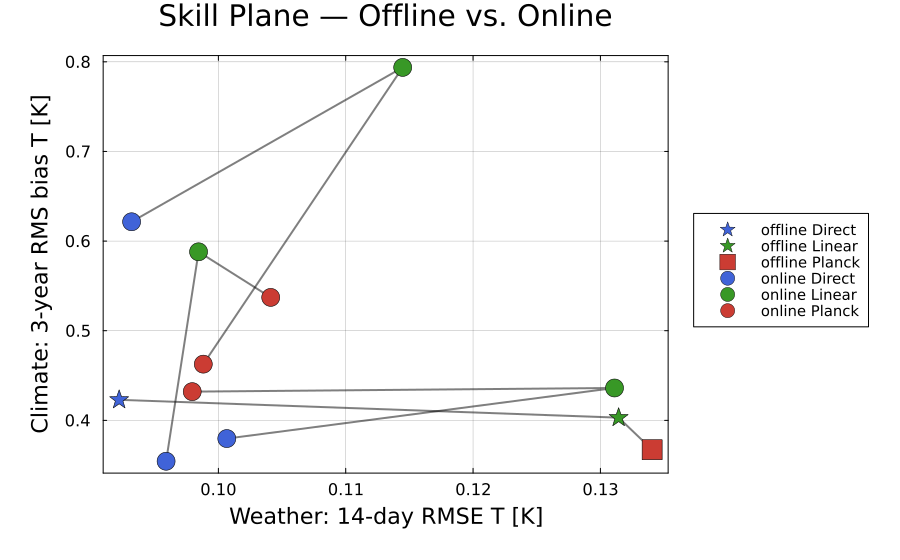

In [33]:
# Define styles and grouping
size_markers = 10

style = (;
    direct_w064_h3 = (; color = JL_BLUE,    size = size_markers, shape = :star,  label = "offline Direct", group = :XXX),
    linear_w064_h3 = (; color = JL_GREEN,   size = size_markers, shape = :star,  label = "offline Linear", group = :XXX),
    planck_w064_h3 = (; color = JL_RED,     size = size_markers, shape = :square,  label = "offline Planck", group = :XXX), 


    direct_eta54_s1 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s1),
    direct_eta54_s2 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s2),
    direct_eta54_s3 = (; color = JL_BLUE,    size = size_markers, shape = :circle,  label = "online Direct", group = :s3),

    linear_eta54_s1 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s1),
    linear_eta54_s2 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s2),
    linear_eta54_s3 = (; color = JL_GREEN,    size = size_markers, shape = :circle,  label = "online Linear", group = :s3),

    planck_eta54_s1 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s1),
    planck_eta54_s2 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s2),
    planck_eta54_s3 = (; color = JL_RED,    size = size_markers, shape = :circle,  label = "online Planck", group = :s3),
)


# Plot skill plane
p = plot_skill_plane(df; style, trace_color = :black, title = "Skill Plane — Offline vs. Online",
        xlabel = "Weather: 14-day RMSE T [K]",
        ylabel = "Climate: 3-year RMS bias T [K]")

In [13]:
# Save plot
Plots.savefig(p, "figures/02_NeuralLW_skillplane.png");

In [36]:
# Define and load "best" units for further evaluation

# Define units
units_direct = [
    "direct_eta54_s1",
    "direct_eta54_s2",
    "direct_eta54_s3",
]
units_planck = [
    "planck_eta54_s1",     
    "planck_eta54_s2",       
    "planck_eta54_s3",
]

# Load rollouts
w_direct = merge(
    collect_rollouts(EXP, SER_ON, units_direct; leg = :weather),
    collect_rollouts(EXP, SER_OFF, ["direct_w064_h3",]; leg = :weather), 
)
w_planck = merge(
    collect_rollouts(EXP, SER_ON, units_planck; leg = :weather),
    collect_rollouts(EXP, SER_OFF, ["planck_w064_h3",]; leg = :weather), 
)

c_direct = merge(
    collect_rollouts(EXP, SER_ON, units_direct; leg = :climate),
    collect_rollouts(EXP, SER_OFF, ["direct_w064_h3",]; leg = :climate), 
)
c_planck = merge(
    collect_rollouts(EXP, SER_ON, units_planck; leg = :climate),
    collect_rollouts(EXP, SER_OFF, ["planck_w064_h3",]; leg = :climate), 
)

w_total = merge(w_direct, w_planck)
c_total = merge(c_direct, c_planck);


In [37]:
# Labels
labels_direct = [
    "online Direct S1",
    "online Direct S2",
    "online Direct S3",
    "offline Direct",
]
labels_planck = [
    "online Planck S1",
    "online Planck S2",
    "online Planck S3",
    "offline Planck",
]

labels_total = [labels_direct..., labels_planck...]

# Colors
colors_direct = [
    JL_BLUE,
    JL_BLUE,
    JL_BLUE,
    :black,
]
colors_planck = [
    JL_RED,
    JL_RED,
    JL_RED,
    :black,
]

colors_total = [colors_direct..., colors_planck...]


styles = [
    :solid,
    :solid,
    :solid,
    :solid,
];

styles_total = [styles..., styles...];

## **3. Weather**

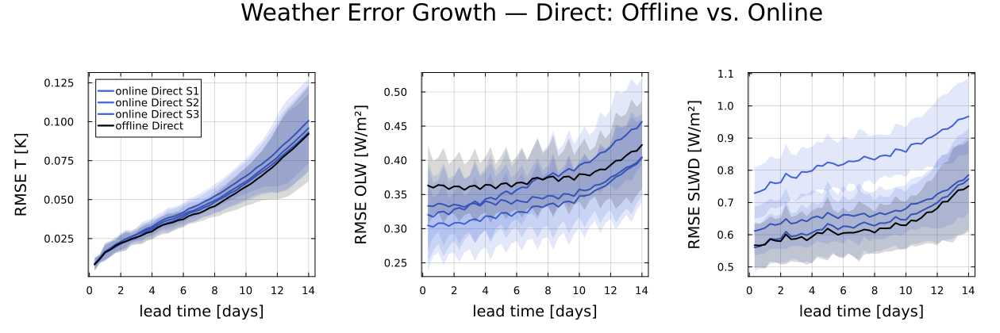

In [50]:
# Plot weather
p = plot_weather(w_direct, :rmse; labels=labels_direct, colors=colors_direct, styles, band = true, plot_config = (; plot_title = "Weather Error Growth — Direct: Offline vs. Online"))

In [51]:
# Save plot
Plots.savefig(p, "figures/02_NeuralLW_weather_direct.png");

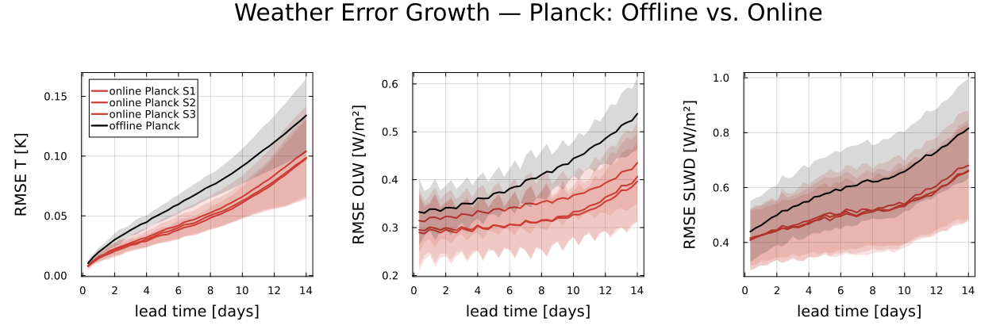

In [53]:
# Plot weather
p = plot_weather(w_planck, :rmse; labels=labels_planck, colors=colors_planck, styles, band = true, plot_config = (; plot_title = "Weather Error Growth — Planck: Offline vs. Online"))

In [54]:
# Save plot
Plots.savefig(p, "figures/02_NeuralLW_weather_planck.png");

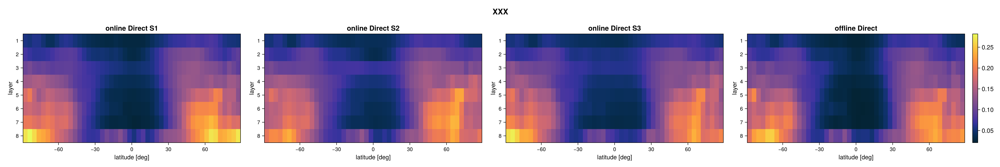

In [40]:
# Plot weather
plot_weather_sections(w_direct, :T, 14; metric = :rmse, labels=labels_direct, suptitle = "XXX", ncols=4)

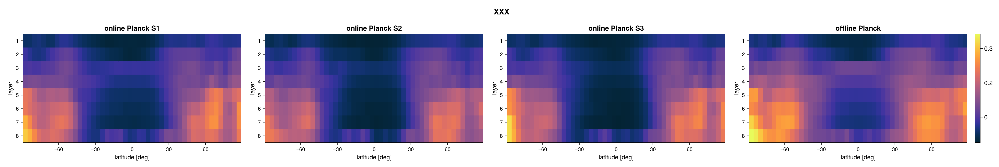

In [41]:
# Plot weather
plot_weather_sections(w_planck, :T, 14; metric = :rmse, labels=labels_planck, suptitle = "XXX", ncols=4)

## **4. Climate**

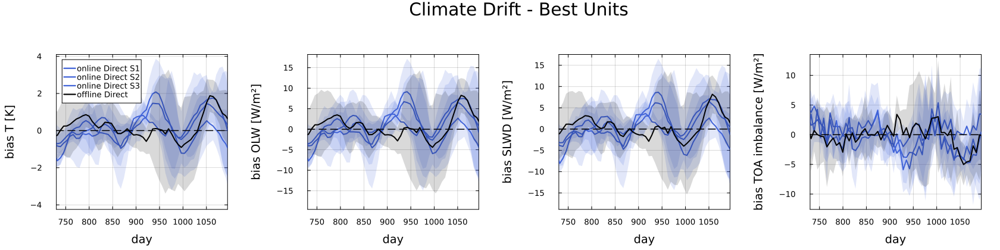

In [47]:
# Plot climate
plot_drift(c_direct; labels = labels_direct, colors = colors_direct, styles, band = true, plot_config = (; plot_title = "Climate Drift - Best Units", xlims = (2*365, 3*365)))

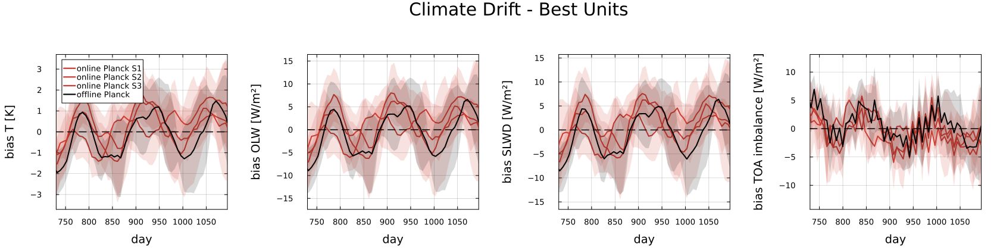

In [48]:
# Plot climate
plot_drift(c_planck; labels = labels_planck, colors = colors_planck, styles, band = true, plot_config = (; plot_title = "Climate Drift - Best Units", xlims = (2*365, 3*365)))

In [54]:
# Create table for survival statistics
sort(climate_table(c), :unit; by = u -> something(findfirst(==(u), units), typemax(Int)))

Row,unit,survived,alive,drift_T,drift_olw,drift_slwd,rms_T,rms_olw,rms_slwd,drift,rms,pct
,String,Float32,Int64,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32
1,planck_eta54_s1,1098.0,4,0.31431,1.47055,1.55482,0.400997,1.90539,2.29035,0.0462844,0.0610623,46.4
2,planck_eta54_s2,1098.0,4,0.249659,0.917485,0.90073,0.325518,1.3316,1.59922,0.0303534,0.0440485,5.6
3,planck_eta54_s3,1098.0,4,0.292647,1.22515,1.22243,0.379275,1.62797,1.85442,0.0392128,0.05279,26.5
4,direct_w064_h3,1098.0,4,0.238269,0.776534,0.710807,0.314182,1.2391,1.56344,0.0265157,0.0417172,0.0


In [60]:
using CairoMakie

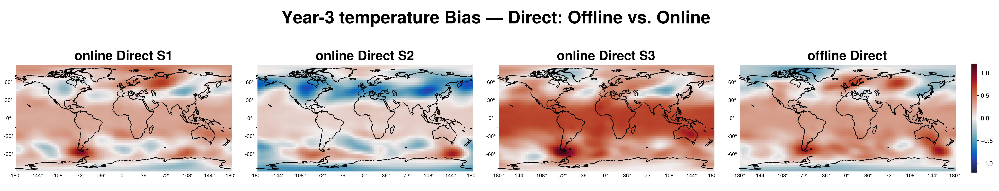

In [61]:
# Plot T bias map
p = plot_climate_maps(c_direct, :T; labels = labels_direct, suptitle = "Year-3 temperature Bias — Direct: Offline vs. Online", ncols = 4,     panel_config = merge(HEATMAP_CONFIG, (; titlesize = 30, suptitlesize = 40)))

In [62]:
# Save plot
CairoMakie.save("figures/02_ClimateHeatmap_direct.png", p);

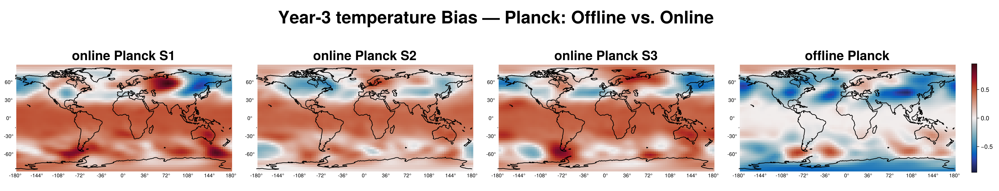

In [63]:
# Plot T bias map
p = plot_climate_maps(c_planck, :T; labels = labels_planck, suptitle = "Year-3 temperature Bias — Planck: Offline vs. Online", ncols = 4,     panel_config = merge(HEATMAP_CONFIG, (; titlesize = 30, suptitlesize = 40)))

In [64]:
# Save plot
CairoMakie.save("figures/02_ClimateHeatmap_planck.png", p);

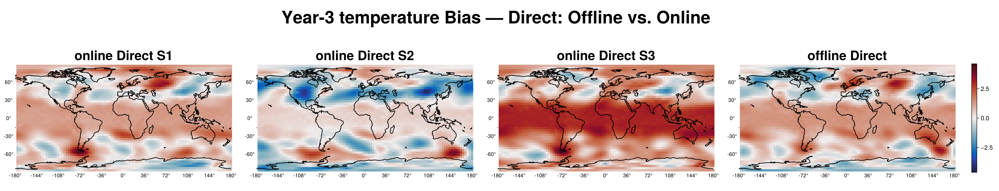

In [65]:
# Plot T bias map
p = plot_climate_maps(c_direct, :olw; labels = labels_direct, suptitle = "Year-3 temperature Bias — Direct: Offline vs. Online", ncols = 4,     panel_config = merge(HEATMAP_CONFIG, (; titlesize = 30, suptitlesize = 40)))

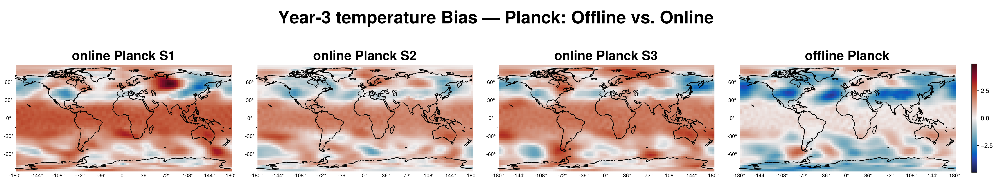

In [66]:
# Plot T bias map
p = plot_climate_maps(c_planck, :olw; labels = labels_planck, suptitle = "Year-3 temperature Bias — Planck: Offline vs. Online", ncols = 4,     panel_config = merge(HEATMAP_CONFIG, (; titlesize = 30, suptitlesize = 40)))